<a href="https://colab.research.google.com/github/Bivasgithub/Sea_Breeze_Front/blob/main/3rd_SB_days_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modification recomended by Aviv**

        Date           Station  n1       dsh  Good_SB t1_time
0 2025-06-01            Ashdod   6  0.578704    False   05:10
1 2025-06-01      Hafez_Hayyim  24  1.755845     True   08:10
2 2025-06-01             Tzuba  39  1.051815     True   10:40
3 2025-06-01  Jerusalem_Centre  41  0.977272    False   11:00
4 2025-06-01     Maale_Adummim  47  0.549637    False   12:00


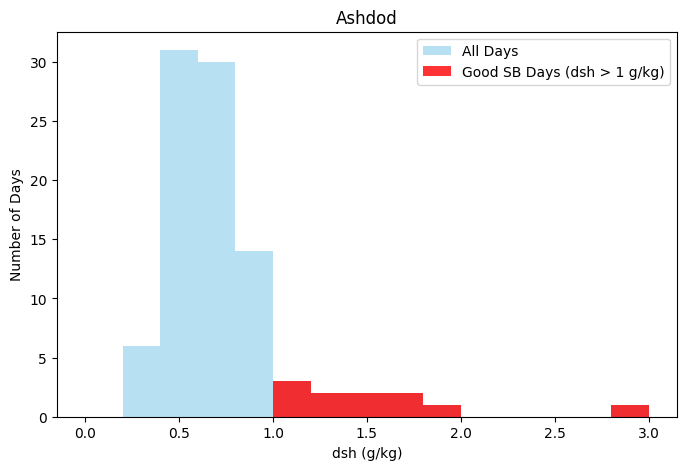

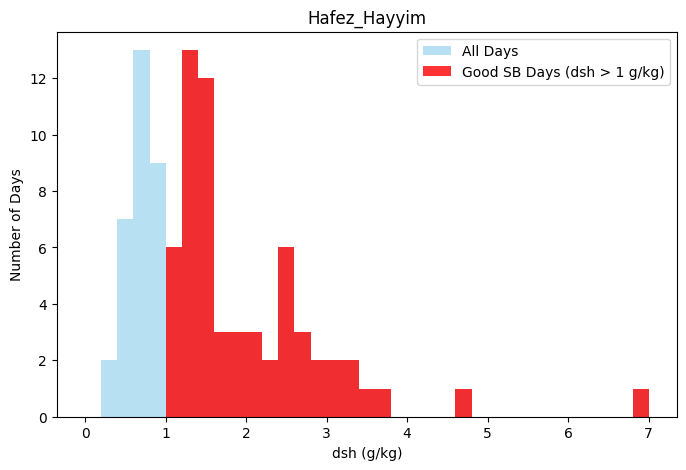

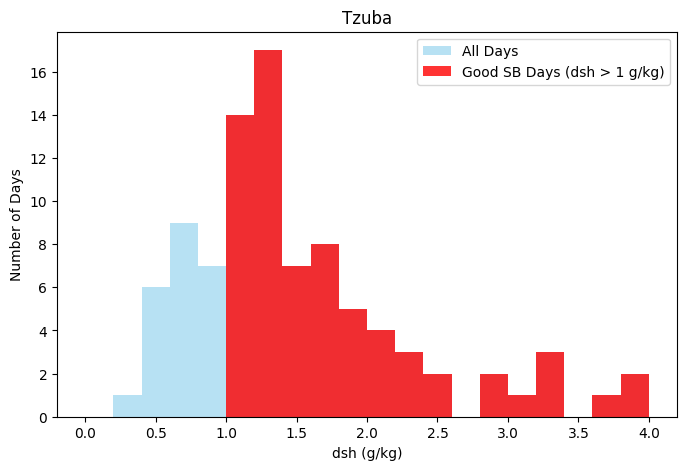

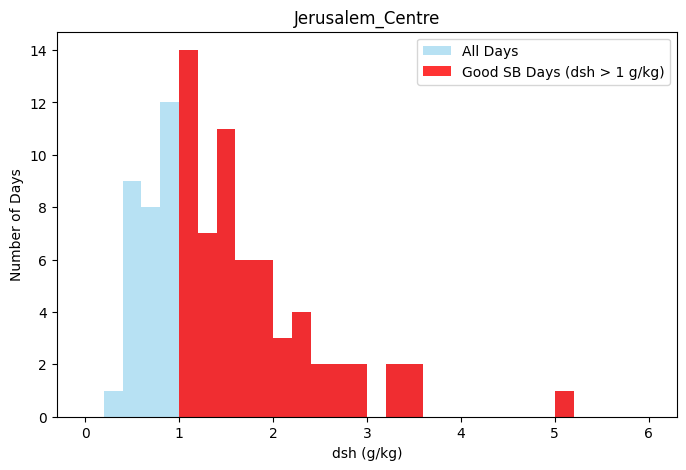

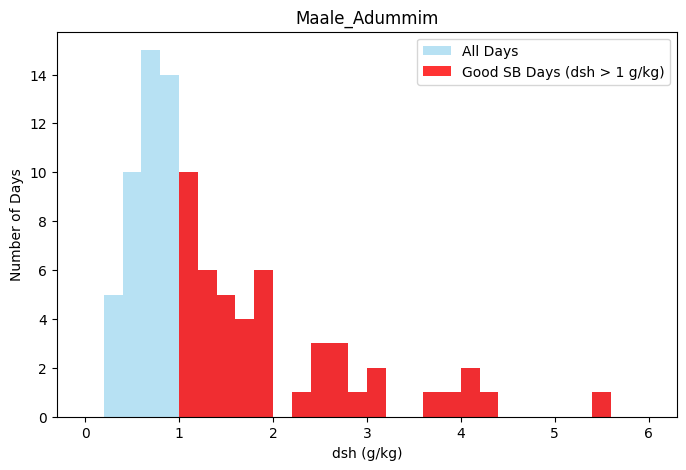



Ashdod
ALL DAYS
Count  : 92
Mean   : 0.7396740097235387
Median : 0.6524475176887048
Std    : 0.38858177135492455
Min    : 0.2038029724847945
Max    : 2.932458682391063

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 11
Mean   : 1.5660878422190478
Median : 1.4456660389406526
Std    : 0.5108543804662452
Min    : 1.0056233010350013
Max    : 2.932458682391063


Hafez_Hayyim
ALL DAYS
Count  : 92
Mean   : 1.5824481991998613
Median : 1.343199163761188
Std    : 1.0270712655002785
Min    : 0.3556175072333936
Max    : 6.854089298403823

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 61
Mean   : 2.022944973258012
Median : 1.5704997118414497
Std    : 1.0003814282333816
Min    : 1.0041467674894893
Max    : 6.854089298403823


Tzuba
ALL DAYS
Count  : 92
Mean   : 1.4876364866099856
Median : 1.3137871948383921
Std    : 0.7872397870510708
Min    : 0.24283117754438166
Max    : 3.9303410889724724

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 69
Mean   : 1.7516720249234174
Median : 1.4675264724542654
Std    : 0.7309650034766544
Mi

In [ ]:
fixed_mid_t1_interval = {
    "Ashdod": "06:20",
    "Hafez_Hayyim": "08:50",
    "Tzuba": "10:30",
    "Jerusalem_Centre": "10:50",
    "Maale_Adummim": "11:40"
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FUNCTION TO COMPUTE t1, t2, t3 & dsh
def compute_sbf_trend(file_path, station, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[["Date & Time (UTC)", "Wind speed (m/s)", "Wind direction (°)",
            "Relative humidity (%)", "Temperature (°C)"]].copy()

    df.columns = df.columns.str.strip()
    numeric_cols = ["Wind speed (m/s)", "Wind direction (°)",
                    "Relative humidity (%)", "Temperature (°C)"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"],
                                             dayfirst=True)

    df.set_index("Date & Time (UTC)", inplace=True)
    # FILTER DAY
    df = df[(df.index.year == year) & (df.index.month == month) &
     (df.index.day == day)].between_time("04:00", "16:00")
    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)
    df["V_onshore"] = (df["u"] * np.sin(alpha) + df["v"] * np.cos(alpha))

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 10, 20])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(df["Temperature (°C)"])
    df["q_3point_slope"] = moving_slope(df["q_gkg"])

    df["Vonshore_3point_slope"] = moving_slope(df["V_onshore"])
    df = df.dropna()

    if len(df) < 3:
        return None

    # FIXED WINDOW ±2 HOURS
    target_time = pd.Timestamp(fixed_mid_t1_interval[station]).time()

    target_minutes = (target_time.hour * 60 + target_time.minute)
    data_minutes = (df.index.hour * 60 + df.index.minute)
    window_mask = (np.abs(data_minutes - target_minutes)<= 120)

    candidate_indices = np.where(window_mask)[0]

    # Find t1 using ORIGINAL definition
    best_slope = -np.inf
    best_n1 = None
    best_t1 = pd.NaT

    for n1 in candidate_indices:
      if (n1 < 1) or (n1 > len(df)-2):
        continue

      if df["V_onshore"].iloc[n1] <= 0:
        continue

      slope_candidate = (df["q_3point_slope"].iloc[n1])
      if slope_candidate > best_slope:

        best_slope = slope_candidate
        best_n1 = n1
        best_t1 = df.index[n1]

    # Compute dsh at selected t1
    t1 = pd.NaT
    dsh = np.nan
    good_sb = False

    if best_n1 is not None:
      t1 = best_t1
      dsh = (
        df["q_gkg"].iloc[best_n1 + 1]
        - df["q_gkg"].iloc[best_n1 - 1])

      dsh_threshold = 1.0
      if dsh > dsh_threshold:
        good_sb = True

    # Optional diagnostics: t2 and t3
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() > 0:
      mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))
      if mask_t2.sum() > 0:
        t2 = df.loc[mask_t2, "q_3point_slope"].idxmax()
      else:
        t2 = pd.NaT

      t3 = df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax()

    else:
      t2 = pd.NaT
      t3 = pd.NaT

    return {"df": df, "t1": t1, "t2": t2, "t3": t3,
            "n1": best_n1, "dsh": dsh, "good_sb": good_sb}


# FILES this is the next part of the code
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}

# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
dsh_all = {station: [] for station in station_files.keys()}

dsh_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []
# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(file, station, year, month, day)
        if result is None:
            continue


        dsh = result["dsh"]
        if np.isnan(dsh):
            continue

        dsh_all[station].append(dsh)
        if result["good_sb"]:
          dsh_good[station].append(dsh)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "n1": result["n1"],
                              "dsh": dsh, "Good_SB": result["good_sb"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})


# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_dsh_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="dsh")
pivot_df.to_excel("dsh_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))
    # all_values = np.concatenate([
    #     dsh_all[station],
    #     dsh_good[station]
    # ])
    if len(dsh_all[station]) == 0:
      continue
    all_values = np.array(dsh_all[station])

    bin_width = 0.2
    bins = np.arange(
        np.floor(np.min(all_values)),
        np.ceil(np.max(all_values)) + bin_width,
        bin_width
    )

    plt.hist(
        dsh_all[station],
        bins=bins,
        alpha=0.6,
        label="All Days",
        color="skyblue"
    )

    plt.hist(
        dsh_good[station],
        bins=bins,
        alpha=0.8,
        label="Good SB Days (dsh > 1 g/kg)",
        color="red"
    )

    plt.xlabel("dsh (g/kg)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()


# STATISTICS
for station in station_files.keys():

    all_vals = np.array(dsh_all[station])

    print("\n")
    print("=" * 60)
    print(station)
    print("=" * 60)

    print("ALL DAYS")
    print("Count  :", len(all_vals))
    if len(all_vals) > 0:

        print("Mean   :", np.mean(all_vals))
        print("Median :", np.median(all_vals))
        print("Std    :", np.std(all_vals))
        print("Min    :", np.min(all_vals))
        print("Max    :", np.max(all_vals))

    good_vals = np.array(dsh_good[station])
    print("\nGOOD SB DAYS (dsh > 1 g/kg)")
    print("Count  :", len(good_vals))

    if len(good_vals) > 0:

        print("Mean   :", np.mean(good_vals))
        print("Median :", np.median(good_vals))
        print("Std    :", np.std(good_vals))
        print("Min    :", np.min(good_vals))
        print("Max    :", np.max(good_vals))

# **Final Combined approach (For Ashdod du3> 2 m/s else: dsh>1 g/kg)**

        Date           Station  n1       dsh  Good_SB t1_time
0 2025-06-01            Ashdod   6  0.578704     True   05:10
1 2025-06-01      Hafez_Hayyim  24  1.755845     True   08:10
2 2025-06-01             Tzuba  39  1.051815     True   10:40
3 2025-06-01  Jerusalem_Centre  41  0.977272    False   11:00
4 2025-06-01     Maale_Adummim  47  0.549637    False   12:00


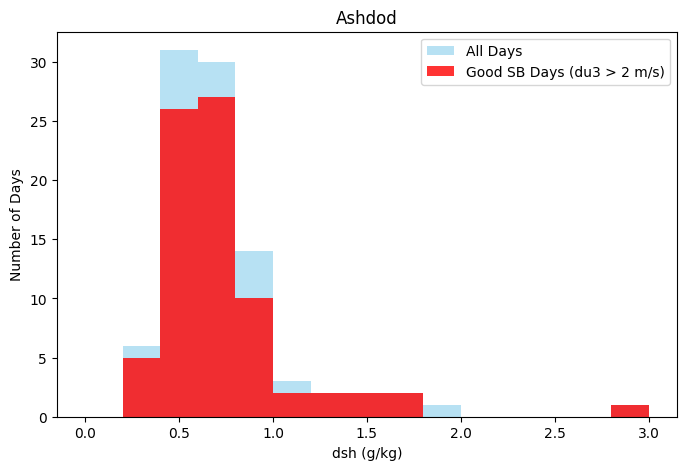

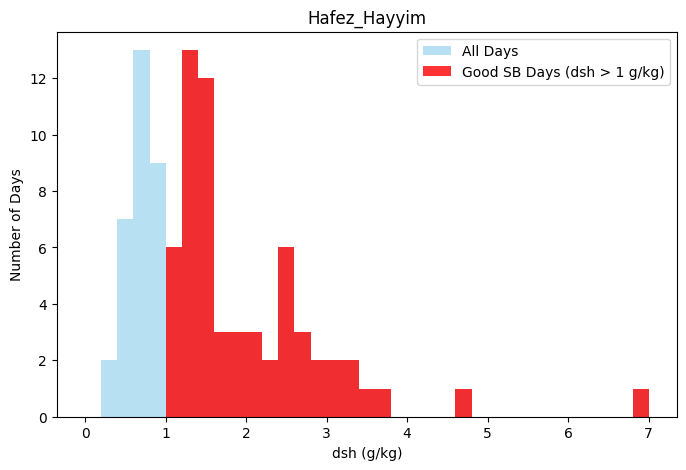

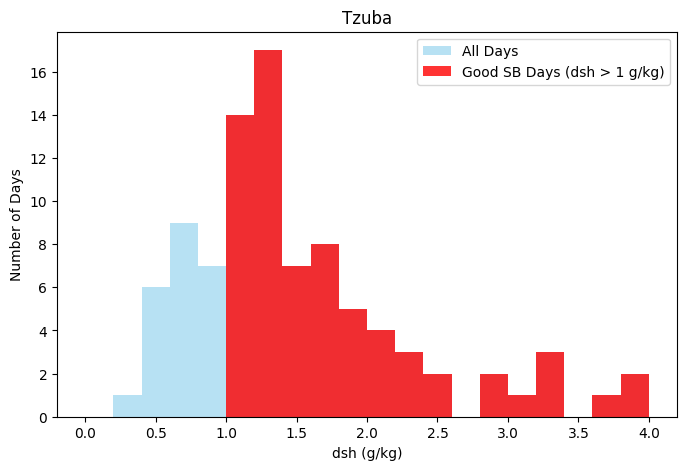

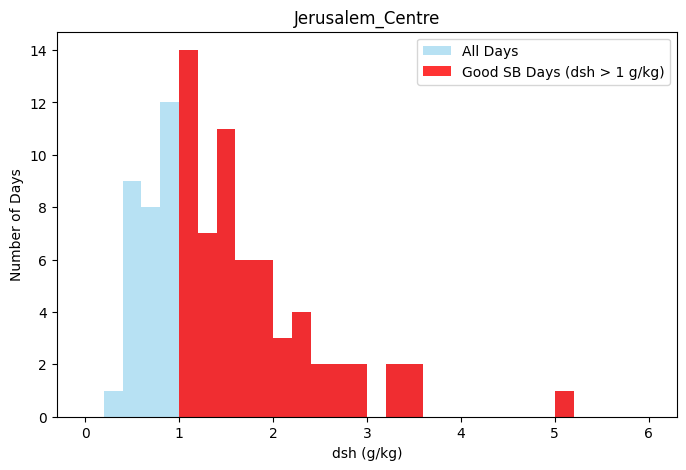

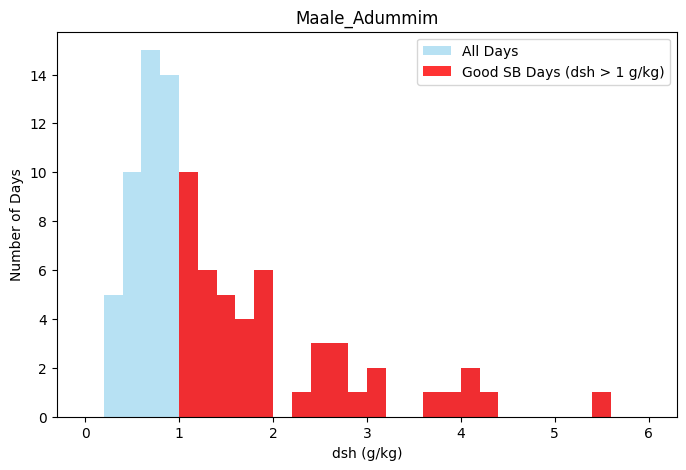



Ashdod
ALL DAYS
Count  : 92
Mean   : 0.7396740097235387
Median : 0.6524475176887048
Std    : 0.38858177135492455
Min    : 0.2038029724847945
Max    : 2.932458682391063

GOOD SB DAYS (du3 > 2 m/s)
Count  : 77
Mean   : 0.7340843624905229
Median : 0.6389263749199365
Std    : 0.38632607742084263
Min    : 0.27680644661923637
Max    : 2.932458682391063


Hafez_Hayyim
ALL DAYS
Count  : 92
Mean   : 1.5824481991998613
Median : 1.343199163761188
Std    : 1.0270712655002785
Min    : 0.3556175072333936
Max    : 6.854089298403823
Count  : 77

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 61
Mean   : 2.022944973258012
Median : 1.5704997118414497
Std    : 1.0003814282333816
Min    : 1.0041467674894893
Max    : 6.854089298403823


Tzuba
ALL DAYS
Count  : 92
Mean   : 1.4876364866099856
Median : 1.3137871948383921
Std    : 0.7872397870510708
Min    : 0.24283117754438166
Max    : 3.9303410889724724
Count  : 61

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 69
Mean   : 1.7516720249234174
Median : 1.4675264724542654
Std  

In [ ]:
fixed_mid_t1_interval = {
    "Ashdod": "06:20",
    "Hafez_Hayyim": "08:50",
    "Tzuba": "10:30",
    "Jerusalem_Centre": "10:50",
    "Maale_Adummim": "11:40"
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FUNCTION TO COMPUTE t1, t2, t3 & dsh
def compute_sbf_trend(file_path, station, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[["Date & Time (UTC)", "Wind speed (m/s)", "Wind direction (°)",
            "Relative humidity (%)", "Temperature (°C)"]].copy()

    df.columns = df.columns.str.strip()
    numeric_cols = ["Wind speed (m/s)", "Wind direction (°)",
                    "Relative humidity (%)", "Temperature (°C)"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"],
                                             dayfirst=True)

    df.set_index("Date & Time (UTC)", inplace=True)
    # FILTER DAY
    df = df[(df.index.year == year) & (df.index.month == month) &
     (df.index.day == day)].between_time("04:00", "16:00")
    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)
    df["V_onshore"] = (df["u"] * np.sin(alpha) + df["v"] * np.cos(alpha))

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 10, 20])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(df["Temperature (°C)"])
    df["q_3point_slope"] = moving_slope(df["q_gkg"])

    df["Vonshore_3point_slope"] = moving_slope(df["V_onshore"])
    df = df.dropna()

    if len(df) < 3:
        return None

    # FIXED WINDOW ±2 HOURS
    target_time = pd.Timestamp(fixed_mid_t1_interval[station]).time()

    target_minutes = (target_time.hour * 60 + target_time.minute)
    data_minutes = (df.index.hour * 60 + df.index.minute)
    window_mask = (np.abs(data_minutes - target_minutes)<= 120)

    candidate_indices = np.where(window_mask)[0]

    # Find t1 using ORIGINAL definition
    best_slope = -np.inf
    best_n1 = None
    best_t1 = pd.NaT

    for n1 in candidate_indices:
      if (n1 < 1) or (n1 > len(df)-2):
        continue

      if df["V_onshore"].iloc[n1] <= 0:
        continue

      slope_candidate = (df["q_3point_slope"].iloc[n1])
      if slope_candidate > best_slope:

        best_slope = slope_candidate
        best_n1 = n1
        best_t1 = df.index[n1]


    #Optional diagnostics: t2 and t3
    mask_u_positive = df["V_onshore"] > 0
    t2 = pd.NaT
    t3 = pd.NaT
    du3 = np.nan

    if mask_u_positive.sum() > 0:
      # t2
      mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))

      if mask_t2.sum() > 0:
        t2 = df.loc[mask_t2, "q_3point_slope"].idxmax()

      # t3
      if station == "Ashdod":
        target_time = pd.Timestamp(fixed_mid_t1_interval["Ashdod"]).time()

        target_minutes = (target_time.hour * 60 + target_time.minute)
        data_minutes = (df.index.hour * 60 + df.index.minute)

        # ±2 h window around 06:20
        window_mask = (np.abs(data_minutes - target_minutes)<= 120)

        candidate_mask = (mask_u_positive & window_mask)
        if candidate_mask.sum() > 0:
            t3 = df.loc[candidate_mask, "Vonshore_3point_slope"].idxmax()
            n3 = df.index.get_loc(t3)

            # 1 hour before to 1 hour after
            if (n3 >= 6) and (n3 <= len(df) - 7):
                du3 = (df["V_onshore"].iloc[n3 + 6] - df["V_onshore"].iloc[n3 - 6])
    else:
        t3 = df.loc[mask_u_positive,"Vonshore_3point_slope"].idxmax()

    # C ompute dsh using t1
    t1 = pd.NaT
    dsh = np.nan

    if best_n1 is not None:
      t1 = best_t1
      dsh = (df["q_gkg"].iloc[best_n1 + 1] - df["q_gkg"].iloc[best_n1 - 1])

    # Good Sea-Breeze Criterion
    good_sb = False
    if station == "Ashdod":
      du3_threshold = 2.0      # change as desired

      if not np.isnan(du3):
        if du3 > du3_threshold:
            good_sb = True

    else:
      dsh_threshold = 1.0

      if not np.isnan(dsh):
        if dsh > dsh_threshold:
            good_sb = True

    return {"df": df, "t1": t1, "t2": t2, "t3": t3,
            "n1": best_n1, "dsh": dsh, "du3": du3, "good_sb": good_sb}


# FILES this is the next part of the code
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}

# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
dsh_all = {station: [] for station in station_files.keys()}

dsh_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []
# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(file, station, year, month, day)
        if result is None:
            continue


        dsh = result["dsh"]
        if np.isnan(dsh):
            continue

        dsh_all[station].append(dsh)
        if result["good_sb"]:
          dsh_good[station].append(dsh)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "n1": result["n1"],
                              "dsh": dsh, "Good_SB": result["good_sb"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})


# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_dsh_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="dsh")
pivot_df.to_excel("dsh_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))

    if len(dsh_all[station]) == 0:
      continue
    all_values = np.array(dsh_all[station])

    bin_width = 0.2
    bins = np.arange(
        np.floor(np.min(all_values)),
        np.ceil(np.max(all_values)) + bin_width,
        bin_width
    )

    plt.hist(
        dsh_all[station],
        bins=bins,
        alpha=0.6,
        label="All Days",
        color="skyblue"
    )

    # Different label for Ashdod
    if station == "Ashdod":
        good_label = "Good SB Days (du3 > 2 m/s)"
    else:
        good_label = "Good SB Days (dsh > 1 g/kg)"

    plt.hist(
        dsh_good[station],
        bins=bins,
        alpha=0.8,
        label=good_label,
        color="red"
    )

    plt.xlabel("dsh (g/kg)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()

# STATISTICS
for station in station_files.keys():

    all_vals = np.array(dsh_all[station])

    print("\n")
    print("=" * 60)
    print(station)
    print("=" * 60)

    print("ALL DAYS")
    print("Count  :", len(all_vals))
    if len(all_vals) > 0:

        print("Mean   :", np.mean(all_vals))
        print("Median :", np.median(all_vals))
        print("Std    :", np.std(all_vals))
        print("Min    :", np.min(all_vals))
        print("Max    :", np.max(all_vals))

    if station == "Ashdod":
      good_days = "\nGOOD SB DAYS (du3 > 2 m/s)"
    else:
      good_days = "\nGOOD SB DAYS (dsh > 1 g/kg)"
      print("Count  :", len(good_vals))

    good_vals = np.array(dsh_good[station])
    print(good_days)
    print("Count  :", len(good_vals))

    if len(good_vals) > 0:

        print("Mean   :", np.mean(good_vals))
        print("Median :", np.median(good_vals))
        print("Std    :", np.std(good_vals))
        print("Min    :", np.min(good_vals))
        print("Max    :", np.max(good_vals))

# **SB Days using t1 & dsh with threshold changing**


        Date           Station       dsh  Good_SB t1_time
0 2025-06-01            Ashdod  0.578704    False   05:10
1 2025-06-01      Hafez_Hayyim  1.755845     True   08:10
2 2025-06-01             Tzuba  2.478484     True   06:30
3 2025-06-01  Jerusalem_Centre  1.626157     True   07:50
4 2025-06-01     Maale_Adummim  0.565647    False   14:40


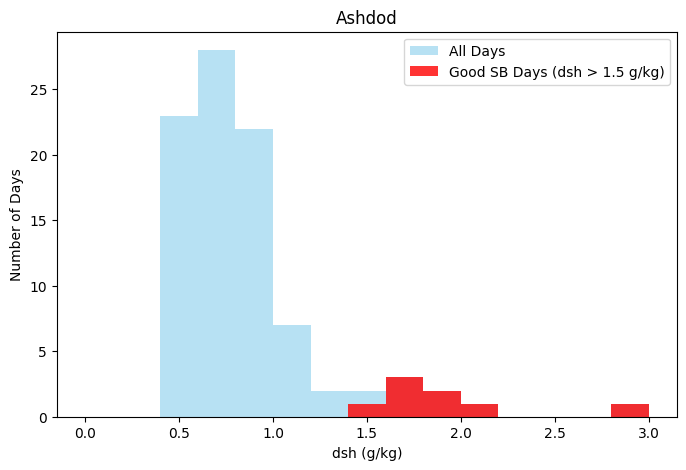

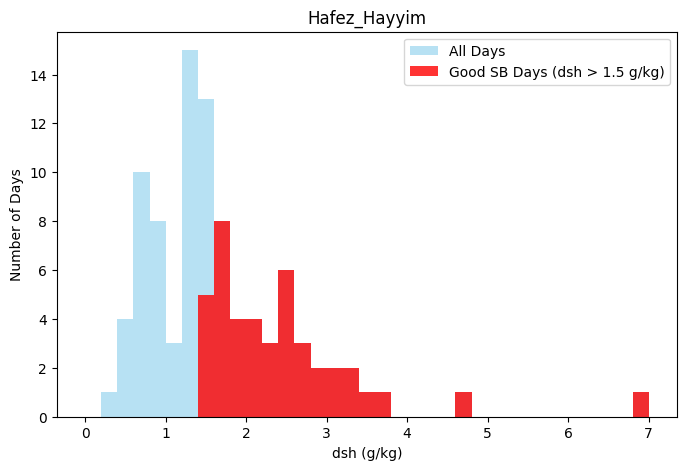

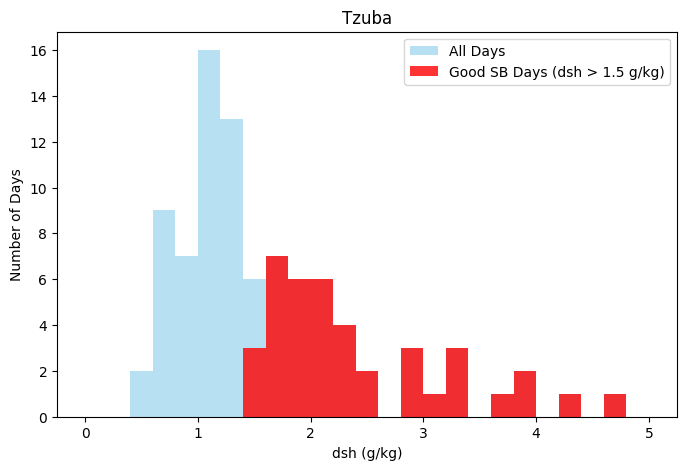

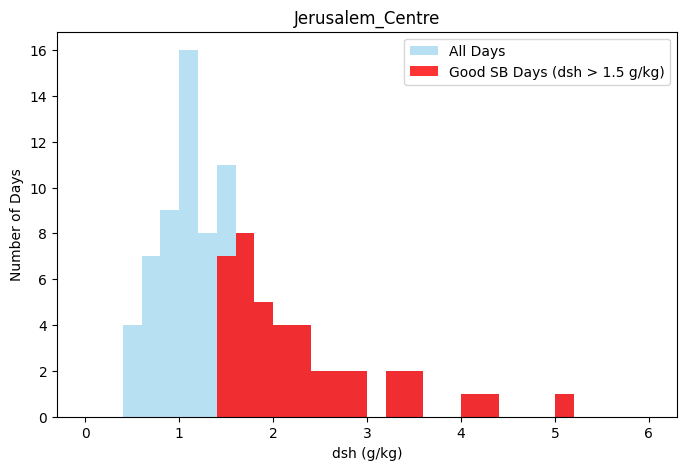

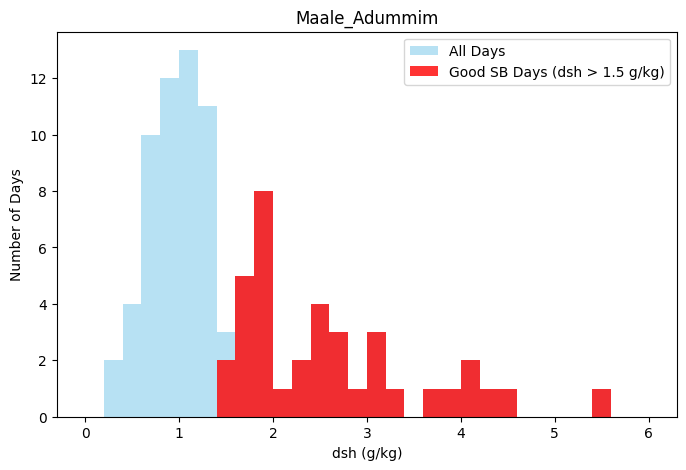

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FUNCTION TO COMPUTE t1, t2, t3 & dsh
def compute_sbf_trend(file_path, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[["Date & Time (UTC)", "Wind speed (m/s)", "Wind direction (°)",
            "Relative humidity (%)", "Temperature (°C)"]].copy()

    df.columns = df.columns.str.strip()
    numeric_cols = ["Wind speed (m/s)", "Wind direction (°)",
                    "Relative humidity (%)", "Temperature (°C)"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"],
                                             dayfirst=True)

    df.set_index("Date & Time (UTC)", inplace=True)
    # FILTER DAY
    df = df[(df.index.year == year) & (df.index.month == month) &
     (df.index.day == day)].between_time("04:00", "16:00")
    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)
    df["V_onshore"] = (df["u"] * np.sin(alpha) + df["v"] * np.cos(alpha))

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(df["Temperature (°C)"])
    df["q_3point_slope"] = moving_slope(df["q_gkg"])

    df["Vonshore_3point_slope"] = moving_slope(df["V_onshore"])
    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0
    if mask_u_positive.sum() == 0:
        return None

    # Strongest moisture increase
    t1 = df.loc[mask_u_positive, "q_3point_slope"].idxmax()
    mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))

    if mask_t2.sum() > 0:
        t2 = df.loc[mask_t2, "q_3point_slope"].idxmax()
    else:
        t2 = pd.NaT

    t3 = df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax()
    # COMPUTE dsh
    dsh = np.nan
    try:
        n1 = df.index.get_loc(t1)
        if (n1 > 0) and (n1 < len(df)-1):
            dsh = (df["q_gkg"].iloc[n1+1] - df["q_gkg"].iloc[n1-1])
    except:
        pass

    # GOOD SB DAY?
    dsh_threshold = 1.5
    good_sb = False

    if not np.isnan(dsh):
        good_sb = dsh > dsh_threshold

    return {"df": df, "t1": t1, "t2": t2, "t3": t3, "dsh": dsh, "good_sb": good_sb}


# FILES
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
dsh_all = {station: [] for station in station_files.keys()}

dsh_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []
# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(file, year, month, day)
        if result is None:
            continue

        dsh = result["dsh"]
        if np.isnan(dsh):
            continue


        dsh_all[station].append(dsh)

        if result["good_sb"]:
          dsh_good[station].append(dsh)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "dsh": dsh,
                              "Good_SB": result["good_sb"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})

# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_dsh_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="dsh")
pivot_df.to_excel("dsh_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))
    all_values = np.concatenate([
        dsh_all[station],
        dsh_good[station]
    ])

    bin_width = 0.2
    bins = np.arange(
        np.floor(np.min(all_values)),
        np.ceil(np.max(all_values)) + bin_width,
        bin_width
    )

    plt.hist(
        dsh_all[station],
        bins=bins,
        alpha=0.6,
        label="All Days",
        color="skyblue"
    )

    plt.hist(
        dsh_good[station],
        bins=bins,
        alpha=0.8,
        label="Good SB Days (dsh > 1.5 g/kg)",
        color="red"
    )

    plt.xlabel("dsh (g/kg)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()


In [ ]:
# STATISTICS
for station in station_files.keys():

    all_vals = np.array(dsh_all[station])

    print("\n")
    print("=" * 60)
    print(station)
    print("=" * 60)

    print("ALL DAYS")
    print("Count  :", len(all_vals))
    if len(all_vals) > 0:

        print("Mean   :", np.mean(all_vals))
        print("Median :", np.median(all_vals))
        print("Std    :", np.std(all_vals))
        print("Min    :", np.min(all_vals))
        print("Max    :", np.max(all_vals))

    good_vals = np.array(dsh_good[station])
    print("\nGOOD SB DAYS (dsh > 1 g/kg)")
    print("Count  :", len(good_vals))

    if len(good_vals) > 0:

        print("Mean   :", np.mean(good_vals))
        print("Median :", np.median(good_vals))
        print("Std    :", np.std(good_vals))
        print("Min    :", np.min(good_vals))
        print("Max    :", np.max(good_vals))



Ashdod
ALL DAYS
Count  : 91
Mean   : 0.8629037589970355
Median : 0.730356585025909
Std    : 0.4181685764336522
Min    : 0.4051934943912592
Max    : 2.932458682391063

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 8
Mean   : 1.9493224842495671
Median : 1.8628943701755247
Std    : 0.40638307645174254
Min    : 1.5395127828326949
Max    : 2.932458682391063


Hafez_Hayyim
ALL DAYS
Count  : 92
Mean   : 1.701115842880987
Median : 1.4749961270575813
Std    : 0.983666363956597
Min    : 0.3758810885490984
Max    : 6.854089298403823

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 43
Mean   : 2.4383120640725333
Median : 2.3012696262438084
Std    : 0.9651637066872948
Min    : 1.5162690548143907
Max    : 6.854089298403823


Tzuba
ALL DAYS
Count  : 90
Mean   : 1.6684926795095767
Median : 1.3813199055768486
Std    : 0.8780548451430429
Min    : 0.46622100760791163
Max    : 4.66473755022104

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 40
Mean   : 2.416399070182949
Median : 2.099839755316057
Std    : 0.8068557993949951
Min    :

# **dsh>2**

        Date           Station       dsh  Good_SB t1_time
0 2025-06-01            Ashdod  0.578704    False   05:10
1 2025-06-01      Hafez_Hayyim  1.755845    False   08:10
2 2025-06-01             Tzuba  2.478484     True   06:30
3 2025-06-01  Jerusalem_Centre  1.626157    False   07:50
4 2025-06-01     Maale_Adummim  0.565647    False   14:40


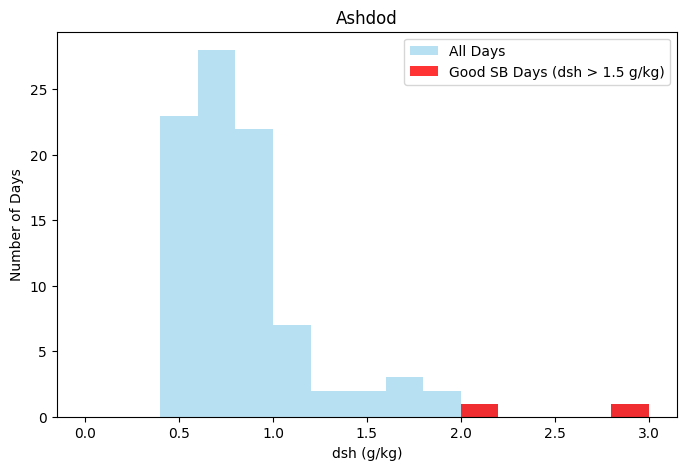

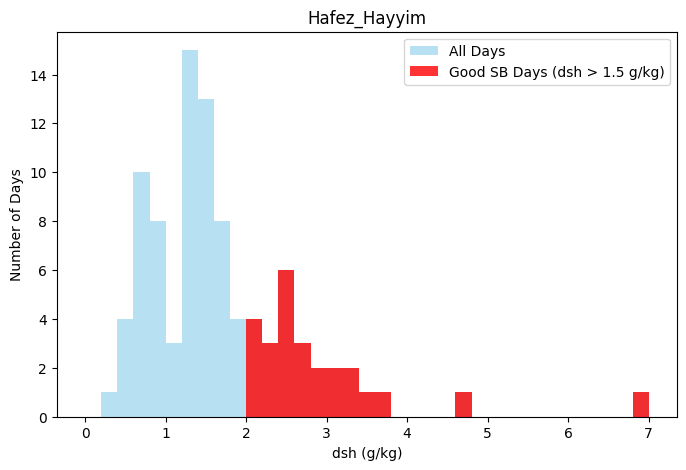

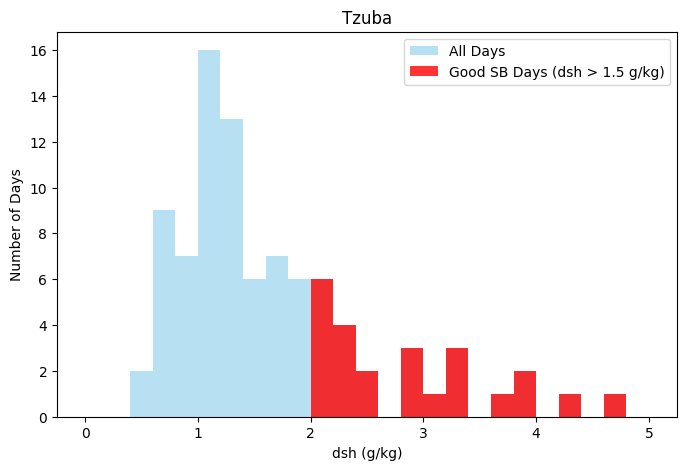

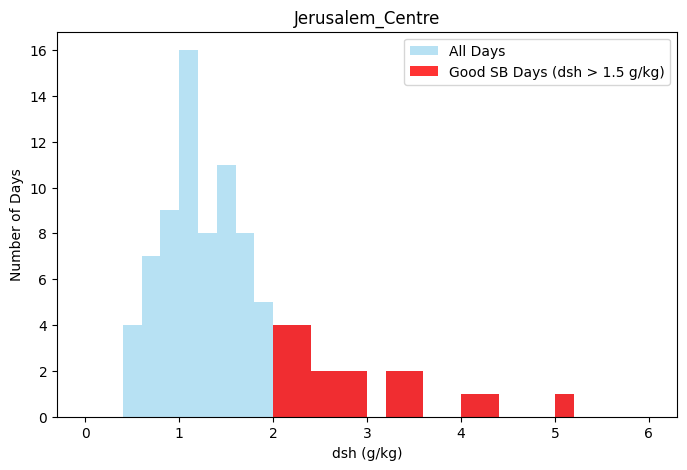

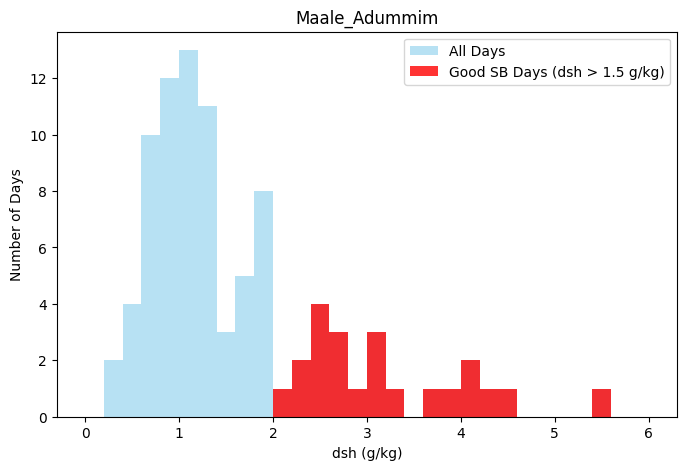

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FUNCTION TO COMPUTE t1, t2, t3 & dsh
def compute_sbf_trend(file_path, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[["Date & Time (UTC)", "Wind speed (m/s)", "Wind direction (°)",
            "Relative humidity (%)", "Temperature (°C)"]].copy()

    df.columns = df.columns.str.strip()
    numeric_cols = ["Wind speed (m/s)", "Wind direction (°)",
                    "Relative humidity (%)", "Temperature (°C)"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"],
                                             dayfirst=True)

    df.set_index("Date & Time (UTC)", inplace=True)
    # FILTER DAY
    df = df[(df.index.year == year) & (df.index.month == month) &
     (df.index.day == day)].between_time("04:00", "16:00")
    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)
    df["V_onshore"] = (df["u"] * np.sin(alpha) + df["v"] * np.cos(alpha))

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(df["Temperature (°C)"])
    df["q_3point_slope"] = moving_slope(df["q_gkg"])

    df["Vonshore_3point_slope"] = moving_slope(df["V_onshore"])
    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0
    if mask_u_positive.sum() == 0:
        return None

    # Strongest moisture increase
    t1 = df.loc[mask_u_positive, "q_3point_slope"].idxmax()
    mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))

    if mask_t2.sum() > 0:
        t2 = df.loc[mask_t2, "q_3point_slope"].idxmax()
    else:
        t2 = pd.NaT

    t3 = df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax()
    # COMPUTE dsh
    dsh = np.nan
    try:
        n1 = df.index.get_loc(t1)
        if (n1 > 0) and (n1 < len(df)-1):
            dsh = (df["q_gkg"].iloc[n1+1] - df["q_gkg"].iloc[n1-1])
    except:
        pass

    # GOOD SB DAY?
    dsh_threshold = 2
    good_sb = False

    if not np.isnan(dsh):
        good_sb = dsh > dsh_threshold

    return {"df": df, "t1": t1, "t2": t2, "t3": t3, "dsh": dsh, "good_sb": good_sb}


# FILES
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
dsh_all = {station: [] for station in station_files.keys()}

dsh_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []
# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(file, year, month, day)
        if result is None:
            continue

        dsh = result["dsh"]
        if np.isnan(dsh):
            continue


        dsh_all[station].append(dsh)

        if result["good_sb"]:
          dsh_good[station].append(dsh)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "dsh": dsh,
                              "Good_SB": result["good_sb"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})

# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_dsh_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="dsh")
pivot_df.to_excel("dsh_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))
    all_values = np.concatenate([
        dsh_all[station],
        dsh_good[station]
    ])

    bin_width = 0.2
    bins = np.arange(
        np.floor(np.min(all_values)),
        np.ceil(np.max(all_values)) + bin_width,
        bin_width
    )

    plt.hist(
        dsh_all[station],
        bins=bins,
        alpha=0.6,
        label="All Days",
        color="skyblue"
    )

    plt.hist(
        dsh_good[station],
        bins=bins,
        alpha=0.8,
        label="Good SB Days (dsh > 1.5 g/kg)",
        color="red"
    )

    plt.xlabel("dsh (g/kg)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()


In [ ]:
# STATISTICS
for station in station_files.keys():

    all_vals = np.array(dsh_all[station])

    print("\n")
    print("=" * 60)
    print(station)
    print("=" * 60)

    print("ALL DAYS")
    print("Count  :", len(all_vals))
    if len(all_vals) > 0:

        print("Mean   :", np.mean(all_vals))
        print("Median :", np.median(all_vals))
        print("Std    :", np.std(all_vals))
        print("Min    :", np.min(all_vals))
        print("Max    :", np.max(all_vals))

    good_vals = np.array(dsh_good[station])
    print("\nGOOD SB DAYS (dsh > 2 g/kg)")
    print("Count  :", len(good_vals))

    if len(good_vals) > 0:

        print("Mean   :", np.mean(good_vals))
        print("Median :", np.median(good_vals))
        print("Std    :", np.std(good_vals))
        print("Min    :", np.min(good_vals))
        print("Max    :", np.max(good_vals))



Ashdod
ALL DAYS
Count  : 91
Mean   : 0.8629037589970355
Median : 0.730356585025909
Std    : 0.4181685764336522
Min    : 0.4051934943912592
Max    : 2.932458682391063

GOOD SB DAYS (dsh > 2 g/kg)
Count  : 2
Mean   : 2.483026648118762
Median : 2.483026648118762
Std    : 0.4494320342723013
Min    : 2.0335946138464607
Max    : 2.932458682391063


Hafez_Hayyim
ALL DAYS
Count  : 92
Mean   : 1.701115842880987
Median : 1.4749961270575813
Std    : 0.983666363956597
Min    : 0.3758810885490984
Max    : 6.854089298403823

GOOD SB DAYS (dsh > 2 g/kg)
Count  : 26
Mean   : 2.9166635982641975
Median : 2.6002032511199387
Std    : 0.9743766973374887
Min    : 2.0405080901080037
Max    : 6.854089298403823


Tzuba
ALL DAYS
Count  : 90
Mean   : 1.6684926795095767
Median : 1.3813199055768486
Std    : 0.8780548451430429
Min    : 0.46622100760791163
Max    : 4.66473755022104

GOOD SB DAYS (dsh > 2 g/kg)
Count  : 24
Mean   : 2.8645395899645187
Median : 2.7129665653251296
Std    : 0.750814130110971
Min    : 2

# **dsh > 2.5**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path_dsh = "/content/dsh_by_station_dsh_2.xlsx"
df_n = pd.read_excel(file_path_dsh, engine="openpyxl")

# Fill NaN values in numeric columns with column means
numeric_cols = df_n.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    df_n[col] = df_n[col].fillna(df_n[col].mean())

# Check remaining missing values
print(df_n.isna().sum())

Date                0
Ashdod              0
Hafez_Hayyim        0
Jerusalem_Centre    0
Maale_Adummim       0
Tzuba               0
dtype: int64


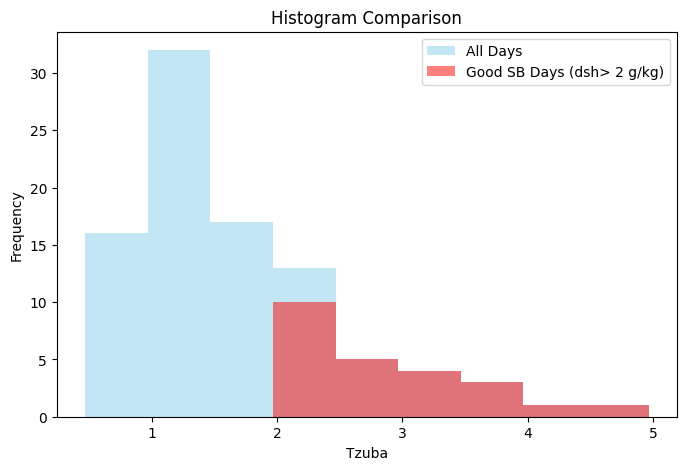

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Second column
values = df_n.iloc[:, 5].dropna()

# Values > 2
values_gt2 = values[values > 2]

# Define a fixed bin width
bin_width = 0.5

# Create common bin edges
bins = np.arange(values.min(), values.max() + bin_width, bin_width)

plt.figure(figsize=(8, 5))

plt.hist(values, bins=bins, alpha=0.5, color="skyblue", label='All Days')
plt.hist(values_gt2, bins=bins, alpha=0.5, color="red", label='Good SB Days (dsh> 2 g/kg)')

plt.xlabel(df_n.columns[5])
plt.ylabel('Frequency')
plt.title('Histogram Comparison')
plt.legend()
#plt.grid(alpha=0.3)

plt.show()

In [ ]:
import numpy as np

all_vals = np.array(values)

print("\n")
print("=" * 60)
print("Statistics for All Values")
print("=" * 60)

print("Count  :", len(all_vals))

if len(all_vals) > 0:
    print("Mean   :", np.mean(all_vals))
    print("Median :", np.median(all_vals))
    print("Std    :", np.std(all_vals))
    print("Min    :", np.min(all_vals))
    print("Max    :", np.max(all_vals))

good_vals = np.array(values_gt2)

print("\nStatistics for Values > 2")
print("Count  :", len(good_vals))

if len(good_vals) > 0:
    print("Mean   :", np.mean(good_vals))
    print("Median :", np.median(good_vals))
    print("Std    :", np.std(good_vals))
    print("Min    :", np.min(good_vals))
    print("Max    :", np.max(good_vals))



Statistics for All Values
Count  : 92
Mean   : 1.668492679509577
Median : 1.391877491581305
Std    : 0.8684583291868263
Min    : 0.4662210076079116
Max    : 4.66473755022104

Statistics for Values > 2
Count  : 24
Mean   : 2.8645395899645187
Median : 2.7129665653251296
Std    : 0.750814130110971
Min    : 2.037595590955506
Max    : 4.66473755022104


In [ ]:
#print(df_n.head())
print(df_n.columns)
#print(values[values > 2.5].count())

Index(['Date', 'Ashdod', 'Hafez_Hayyim', 'Jerusalem_Centre', 'Maale_Adummim',
       'Tzuba'],
      dtype='object')


In [ ]:
filtered_df = df_n[(df_n.iloc[:, 2] > 2.5) & (df_n.iloc[:, 3] > 1.5)]
print(filtered_df)

         Date    Ashdod  Hafez_Hayyim  Jerusalem_Centre  Maale_Adummim  \
5  2025-06-06  0.590859      3.466172          1.950927       2.617753   
6  2025-06-07  0.518945      2.674755          2.137358       4.286669   
11 2025-06-12  0.426646      3.084861          2.617933       3.856702   
12 2025-06-13  0.638926      3.378341          1.805702       4.071297   
27 2025-06-28  1.771934      2.957428          2.876585       1.837857   
28 2025-06-29  1.992183      2.603849          2.500768       2.586948   
38 2025-07-09  0.650503      2.596558          1.515463       3.365936   
44 2025-07-15  0.608750      2.983456          3.284261       3.183428   
71 2025-08-11  1.058559      3.353065          1.744265       1.836056   
72 2025-08-12  0.551479      3.117776          2.779462       4.553289   
74 2025-08-14  0.708597      2.757049          4.029902       1.633140   

       Tzuba  
5   1.976340  
6   2.395586  
11  2.905386  
12  2.091780  
27  3.011060  
28  3.224974  
38  1.

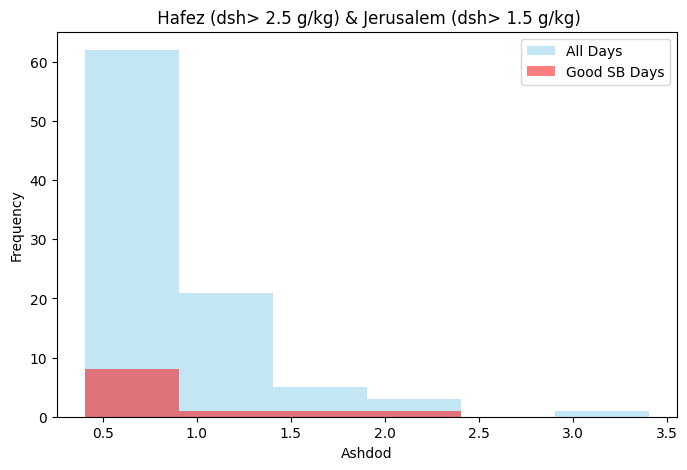

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

values = df_n.iloc[:, 1].dropna()
#values_gt2 = values[values > 2] filtered_df
values_gt2 = filtered_df.iloc[:, 1].dropna()

# Define a fixed bin width
# Create common bin edges
bin_width = 0.5
bins = np.arange(values.min(), values.max() + bin_width, bin_width)

plt.figure(figsize=(8, 5))
plt.hist(values, bins=bins, alpha=0.5, color="skyblue", label='All Days')
plt.hist(values_gt2, bins=bins, alpha=0.5, color="red", label='Good SB Days')

plt.xlabel(df_n.columns[1])
plt.ylabel('Frequency')
plt.title(' Hafez (dsh> 2.5 g/kg) & Jerusalem (dsh> 1.5 g/kg)')
plt.legend()
plt.show()

In [ ]:
filtered_df = df_n[df_n.iloc[:, 1] > 2.5]

output_file = "filtered_rows_gt_2_5.xlsx"
filtered_df.to_excel(output_file, index=False)

print(f"Saved {len(filtered_df)} rows to '{output_file}'")

Saved 1 rows to 'filtered_rows_gt_2_5.xlsx'


# **Hafez dsh>2.0 & Tzuba dsh>1.75 & Jerusalem dsh>1.5**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path_dsh = "/content/dsh_by_station_dsh_2.xlsx"
df_n = pd.read_excel(file_path_dsh, engine="openpyxl")

# Fill NaN values in numeric columns with column means
numeric_cols = df_n.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    df_n[col] = df_n[col].fillna(df_n[col].mean())

# Remaining missing values
print(df_n.isna().sum())

Date                0
Ashdod              0
Hafez_Hayyim        0
Jerusalem_Centre    0
Maale_Adummim       0
Tzuba               0
dtype: int64


In [ ]:
print(df_n.columns)

Index(['Date', 'Ashdod', 'Hafez_Hayyim', 'Jerusalem_Centre', 'Maale_Adummim',
       'Tzuba'],
      dtype='object')


In [ ]:
filtered_df_3 = df_n[(df_n.iloc[:, 2] > 2.5) & (df_n.iloc[:, 3] > 1.5) & (df_n.iloc[:, 5] > 1.75)]
print(filtered_df_3)

         Date    Ashdod  Hafez_Hayyim  Jerusalem_Centre  Maale_Adummim  \
5  2025-06-06  0.590859      3.466172          1.950927       2.617753   
6  2025-06-07  0.518945      2.674755          2.137358       4.286669   
11 2025-06-12  0.426646      3.084861          2.617933       3.856702   
12 2025-06-13  0.638926      3.378341          1.805702       4.071297   
27 2025-06-28  1.771934      2.957428          2.876585       1.837857   
28 2025-06-29  1.992183      2.603849          2.500768       2.586948   
38 2025-07-09  0.650503      2.596558          1.515463       3.365936   
44 2025-07-15  0.608750      2.983456          3.284261       3.183428   
71 2025-08-11  1.058559      3.353065          1.744265       1.836056   
72 2025-08-12  0.551479      3.117776          2.779462       4.553289   

       Tzuba  
5   1.976340  
6   2.395586  
11  2.905386  
12  2.091780  
27  3.011060  
28  3.224974  
38  1.918025  
44  3.327441  
71  2.090323  
72  3.866851  


# **Wind acceleration transition for shore line meteorological stations (Criteria du3 > 2 m/s)**

# **Only for shore line station i.e., Ashdod Station**

# **New Practice**

        Date       du3  Good_SB1  WD_t3_plus1h t1_time t2_time t3_time
0 2025-06-01  4.014013      True         283.0   05:10   05:10   05:40
1 2025-06-02  3.791260      True         273.0   14:50   14:50   05:40
2 2025-06-03 -2.054627     False         327.0   09:50   09:50   14:50
3 2025-06-04  4.247791     False         239.0   05:40   05:40   06:10
4 2025-06-05  3.222144      True         267.0   06:20   06:20   06:50


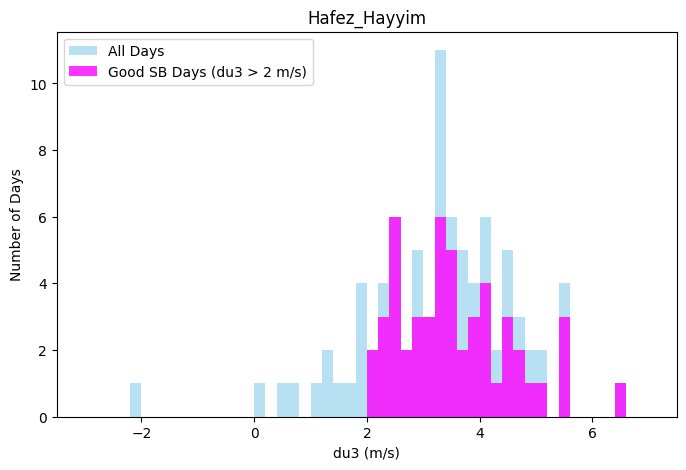

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def compute_sbf_trend(file_path, year, month, day):
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[["Date & Time (UTC)", "Wind speed (m/s)", "Wind direction (°)",
             "Relative humidity (%)", "Temperature (°C)"]].copy()

    df.columns = df.columns.str.strip()
    numeric_cols = ["Wind speed (m/s)", "Wind direction (°)",
                    "Relative humidity (%)", "Temperature (°C)"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DAY
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )


    T_K = df["Temperature (°C)"] + 273.15

    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )
    df["q_gkg"] = df["q"] * 1000


    def moving_slope(series):

        values = series.values

        slopes = [np.nan]

        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)

        return slopes


    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # t1 = strongest moisture increase

    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:

        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()

    else:

        t2 = pd.NaT

    # t3 = strongest increase in onshore wind

    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()


    du3 = np.nan
    wd_after_t3 = np.nan

    try:
      n3 = df.index.get_loc(t3)
      if (n3 >= 6) and (n3 < len(df)-6):
        du3 = (df["V_onshore"].iloc[n3+6] - df["V_onshore"].iloc[n3-6])

        wd_after_t3 = df["Wind direction (°)"].iloc[n3+6]
    except:
      pass

    # GOOD SEA BREEZE DAY?
    good_sb1 = False

    if (not np.isnan(du3) and not np.isnan(wd_after_t3)):
      good_sb1 = (du3 > 2.0 and 240 <= wd_after_t3 <= 330)


    return {
        "df": df,
        "t1": t1,
        "t2": t2,
        "t3": t3,
        "du3": du3,
        "wd_after_t3": wd_after_t3,
        "good_sb1": good_sb1
    }



file_path = "/content/Ashdod_data.xlsx"
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")

du3_all = []
du3_good = []

results_table = []


for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    result = compute_sbf_trend(
        file_path,
        year,
        month,
        day
    )

    if result is None:
        continue

    du3 = result["du3"]

    if np.isnan(du3):
        continue

    du3_all.append(du3)
    if result["good_sb1"]:
        du3_good.append(du3)

    results_table.append({
        "Date": current_date,
        "du3": du3,
        "Good_SB1": result["good_sb1"],
        "WD_t3_plus1h": result["wd_after_t3"],
        "t1_time":
            result["t1"].strftime("%H:%M")
            if pd.notna(result["t1"])
            else None,
        "t2_time":
            result["t2"].strftime("%H:%M")
            if pd.notna(result["t2"])
            else None,
        "t3_time":
            result["t3"].strftime("%H:%M")
            if pd.notna(result["t3"])
            else None
    })


results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Ashdod_du3_results.xlsx", index=False)

plt.figure(figsize=(8, 5))

all_values = np.concatenate([du3_all, du3_good])
bin_width = 0.2
bins = np.arange(np.floor(np.min(all_values)),np.ceil(np.max(all_values)) + bin_width, bin_width)


plt.hist(du3_all, bins=bins, alpha=0.6, label="All Days", color="skyblue")
plt.hist(du3_good, bins=bins, alpha=0.8, label="Good SB Days (du3 > 2 m/s)", color="magenta")
plt.xlabel("du3 (m/s)")
plt.ylabel("Number of Days")
plt.title("Hafez_Hayyim")
plt.legend()

plt.show()



In [ ]:

all_vals = np.array(du3_all)

print("\n")
print("=" * 60)
print(station)
print("=" * 60)

print("ALL DAYS")
print("Count  :", len(all_vals))

if len(all_vals) > 0:

    print("Mean   :", np.mean(all_vals))
    print("Median :", np.median(all_vals))
    print("Std    :", np.std(all_vals))
    print("Min    :", np.min(all_vals))
    print("Max    :", np.max(all_vals))

good_vals = np.array(du3_good)

print("\nGOOD SB DAYS (du3 > threshold and 240 <= wd_after_t3 <= 330)")
print("Count  :", len(good_vals))

if len(good_vals) > 0:

    print("Mean   :", np.mean(good_vals))
    print("Median :", np.median(good_vals))
    print("Std    :", np.std(good_vals))
    print("Min    :", np.min(good_vals))
    print("Max    :", np.max(good_vals))



Hafez
ALL DAYS
Count  : 86
Mean   : 3.2650206613899466
Median : 3.3943012278754323
Std    : 1.3248667982597178
Min    : -2.0546265496178746
Max    : 6.461817815444565

GOOD SB DAYS (du3 > threshold and 240 <= wd_after_t3 <= 330)
Count  : 51
Mean   : 3.5669862178964045
Median : 3.4433127348347154
Std    : 0.9811324463438414
Min    : 2.022348654721349
Max    : 6.461817815444565
